# Self‑Adapting Evolution Strategy (ES)

In a self‑adapting ES the mutation step‑sizes (`F`) evolve together with the
solution. The library provides:
- `SelfAdaptingESEncoding` – appends `F` to each genotype (now fixed to use `"F"`).
- `ExtendedInitializer` – initialises solutions and `F` together.
- `AdaptativeOperator` – updates the mutation `F` with current values from the genotype.

We'll optimize the 3‑D **Sphere**, track the evolved `F`, and visualise both.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import metaheuristic_designer as mhd
from metaheuristic_designer.benchmarks import Sphere
from metaheuristic_designer.encodings import SelfAdaptingESEncoding
from metaheuristic_designer.initializers import (
    UniformInitializer,
    ExtendedInitializer,
)
from metaheuristic_designer.operators import AdaptiveOperator
from metaheuristic_designer.survivor_selection import (
    create_survivor_selection,
)

rng = mhd.check_random_state(42)

## 1. Objective function – Sphere in 2D

In [2]:
DIM = 3
objfunc = Sphere(DIM, mode="min")

## 2. Encoding: append `F` to each individual
`single_sigma=False` gives one `F` per dimension. The genotype is `[x1, x2, F1, F2]`.

In [3]:
encoding = SelfAdaptingESEncoding(dimension=DIM, single_sigma=False)

## 3. Initializer – solutions and F
Solutions are uniformly drawn in [-10,10]; F values in [1e-3, 2].


In [5]:
solution_init = UniformInitializer(DIM, -10, 10, population_size=30, random_state=rng)
F_init = UniformInitializer(DIM, 1e-3, 2, population_size=30, random_state=rng)

initializer = ExtendedInitializer(
    solution_init=solution_init,
    param_init_dict={"F": F_init},  # key must match encoding parameter name
    encoding=encoding,
)

## 4. Operators – mutate solution & F

- **Solution mutation**: Gaussian mutation with one component, its `F` will be updated by the adaptative operator.
- **F mutation**: self‑adaptation via log‑normal update (`mutate_n_sigmas` on the F part).
- **AdaptativeOperator** decodes the current `F` from the genotype and passes it to the solution mutation.

In [6]:
solution_mut = mhd.operators.create_operator(
    "mutation.gaussian_mutation",
    N=1,
    F=1.0,  # initial placeholder, will be overwritten each generation
    random_state=rng,
)

F_mut = mhd.operators.create_operator(
    "mutate_n_sigmas",
    epsilon=1e-3,
    tau=0.1,
    tau_multiple=0.2,
    random_state=rng,
)

operator = AdaptiveOperator(
    base_operator=solution_mut,
    param_operators={"F": F_mut},  # key matches encoding & initializer
    encoding=encoding,
)

## 5. Survivor selection – (μ+λ)

In [7]:
survivor_sel = create_survivor_selection("(mu+lambda)", random_state=rng)

## 6. Build strategy and algorithm

In [8]:
strategy = mhd.SearchStrategy(
    initializer=initializer,
    operator=operator,
    survivor_sel=survivor_sel,
    random_state=rng,
)

algo = mhd.algorithms.Algorithm(
    objfunc,
    strategy,
    max_iterations=100,
    stop_cond="max_iterations",
    reporter="tqdm",
)

## 7. Run and track F evolution
We manually step, decode the `F` values from the population, and record their mean.

In [9]:
F_history = []
algo.initialize()
algo.reporter.log_init(algo)
for gen in range(100):
    algo.step()  # Run one step of the algorithm

    # Update internals of the algorithm
    algo.history_tracker.step(algo)
    algo.reporter.log_step(algo)
    algo.stopping_condition.step(algo)

    current_geno = algo.search_strategy.population.genotype_matrix
    params = encoding.decode_params(current_geno)
    F_vals = params["F"]
    F_history.append(F_vals.mean(axis=0))  # store mean per dimension
algo.reporter.log_end(algo)
F_history = np.array(F_history)

population = algo.population

  0%|          |   0% [00:00<?, ?it/s]

## 8. Visualise fitness and F

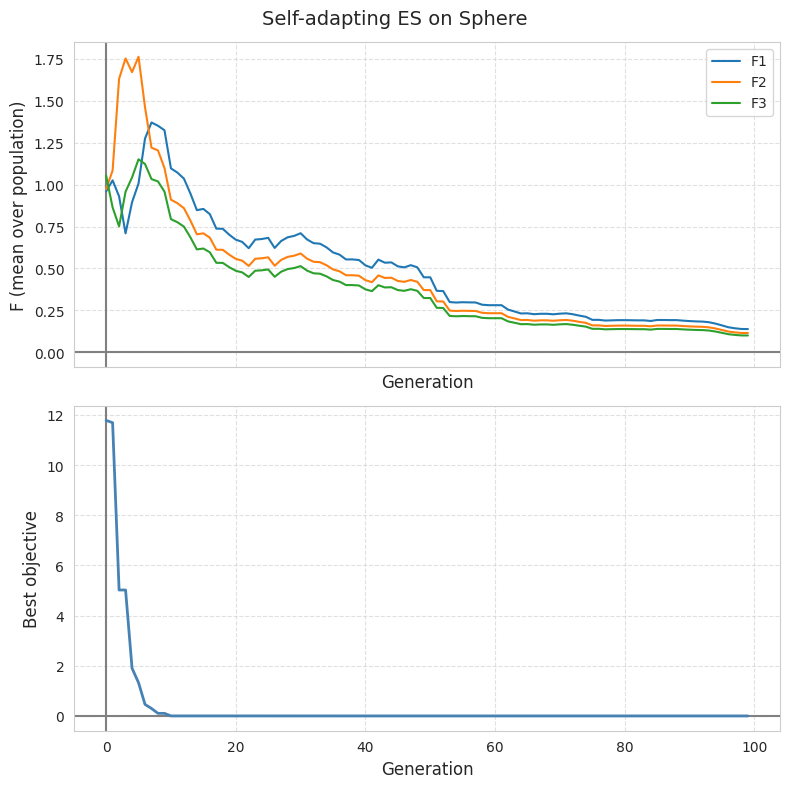

In [10]:
# After the loop,
history_df = algo.history_tracker.to_pandas()

# Then in the plotting cell:
sns.set_style("whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 8))

for d in range(DIM):
    ax1.plot(F_history[:, d], label=f"F{d+1}", zorder=10)
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.set_xlabel("Generation", fontsize=12)
ax1.set_ylabel("F (mean over population)", fontsize=12)
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.axhline(0, color="grey")
ax1.axvline(0, color="grey")
ax1.legend()

# New seaborn-style convergence on ax3
sns.lineplot(data=history_df, x="iteration", y="best_objective", ax=ax2, linewidth=2, color="steelblue", zorder=10)
ax2.set_xlabel("Generation", fontsize=12)
ax2.set_ylabel("Best objective", fontsize=12)
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.axhline(0, color="grey")
ax2.axvline(0, color="grey")

plt.suptitle("Self-adapting ES on Sphere", fontsize=14)
plt.tight_layout()
plt.show()